Notebook 1: Autoencoders para comunicaciones de end-to-end.

El objetivo de este notebook es replicar el paper clásico de O'Shea ("An Introduction to Deep Learning for the Physical Layer"), que demostró que una red neuronal puede aprender sistemas de modulación (como BPSK o QAM) de forma autónoma.

• Entrada: Vectores de bits aleatorios (representados como vectores one-hot).

• Encoder: Capas densas (nn.Linear) que comprimen los bits en un espacio bidimensional (I/Q: En fase y cuadratura).

• Restricción de potencia: Aplicar torch.mean(x ** 2) para normalizar la constelación aprendida.

• Canal: Capa personalizada que añade ruido AWGN usando tu línea torch.randn_like.

• Decoder: Capas densas que intentan clasificar qué bits se enviaron originalmente.


Métricas a graficar:

*   La constelación aprendida en el plano 2D, la red agrupa los puntos de forma similar a una modulación tradicional para protegerse del ruido.
*   La curva de Tasa de Error de Bit (BER) contra a la Relación Señal a Ruido(SNR)

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

#Semilla para reproducibilidad
torch.manual_seed(17)                                                           
np.random.seed(17)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#-------------------------------------------+
# HIPERPARÁMETROS DEL SISTEMA
#-------------------------------------------+
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
simbols = 16                                                                    # Número de símbolos (16-QAM)
k = int(np.log2(simbols))                                                       # Bits por símbolo (4 bits)
chan_dim = 2                                                                    # Dimensión del canal (2D : I(Fase) y Q(Cuadratura))



#-------------------------------------------+
#DEFINICIÓN DEL AUTOENCODER
#-------------------------------------------+
class Autoencoder(nn.Module):
    def __init__(self, simbols=16, chan_dim=2):
        super().__init__()
        #Codifiacador (Transmisor)
        self.encoder = nn.Sequential(                                                          
            nn.Linear(simbols, simbols),
            nn.ReLU(),
            nn.Linear(simbols, chan_dim)                                       # Salida: coordenadas I y Q
        )
        #Decodifiacador (Receptor) 
        self.decoder = nn.Sequential(                                           
            nn.Linear(chan_dim, simbols),
            nn.ReLU(),
            nn.Linear(simbols, simbols)
        )

    def forward(self, x, snr_dB):
        x_simbols = self.encoder(x)
        
        power = torch.mean(x_simbols ** 2)                                     #Restricción de potencia, la potencia promedio de los símbolos debe ser 1
        x_tx = x_simbols / torch.sqrt(power)

        snr_linear = 10 ** (snr_dB / 10.0)                                     #Se convierte la SNR de su escala logarítmica (dB) a escala lineal para los cálculos     
        noise_var = 1.0 / (2 * chan_dim * snr_linear)                          #Como se divide la potencia entre dim_canal, se ajusta la varianza del ruido

        noise = torch.randn_like(x_tx) * torch.sqrt(torch.tensor(noise_var))
        x_rx = x_tx + noise

        out = self.decoder(x_rx)
        return out

In [12]:
#-------------------------------------------+
#ENTRENAMIENTO
#-------------------------------------------+
print(f"Sistemas de transmisión de {k} bits ({simbols} mensajes únicos) en un espacio de {chan_dim}D.")
model = Autoencoder(simbols, chan_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

# Generación de datos de entrenamiento (Mensajes aleatorios del 0 al simbols-1)
max_data = 50000                                                               #Cantidad de datos de entrenamiento
y = torch.randint(0, simbols, (max_data,))                            #Se generan 50000 etiquetas aleatorias de entrenamiento
x = nn.functional.one_hot(y, num_classes=simbols).float()             #A partir de las etiquetas, se generan 50000 datos tipo one hot
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=17, test_size=0.2)

# DataLoader
train_dataset = TensorDataset(x_train, y_train)
bach_size = 1024
train_loader = DataLoader(train_dataset, batch_size=bach_size, shuffle=True)

snr_training = 10

#Bucle de entrenamiento
epochs = 100                                                                 
print(f"Entrenando Autoencoder: {device}...")
model.train()
for i in range(epochs):
    running_loss = 0.0

    for x_batch, y_batch  in train_loader:       

        optimizer.zero_grad()
        outputs = model(x_batch, snr_training)

        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    if (i+1) % 10 == 0:
      print(f"Época {i+1}/{epochs} - Pérdida: {running_loss/(max_data/bach_size):.4f}")

Sistemas de transmisión de 4 bits (16 mensajes únicos) en un espacio de 2D.
Entrenando Autoencoder: cpu...
Época 10/100 - Pérdida: 0.0970
Época 20/100 - Pérdida: 0.0399
Época 30/100 - Pérdida: 0.0256
Época 40/100 - Pérdida: 0.0237
Época 50/100 - Pérdida: 0.0223
Época 60/100 - Pérdida: 0.0170
Época 70/100 - Pérdida: 0.0151
Época 80/100 - Pérdida: 0.0147
Época 90/100 - Pérdida: 0.0159
Época 100/100 - Pérdida: 0.0137


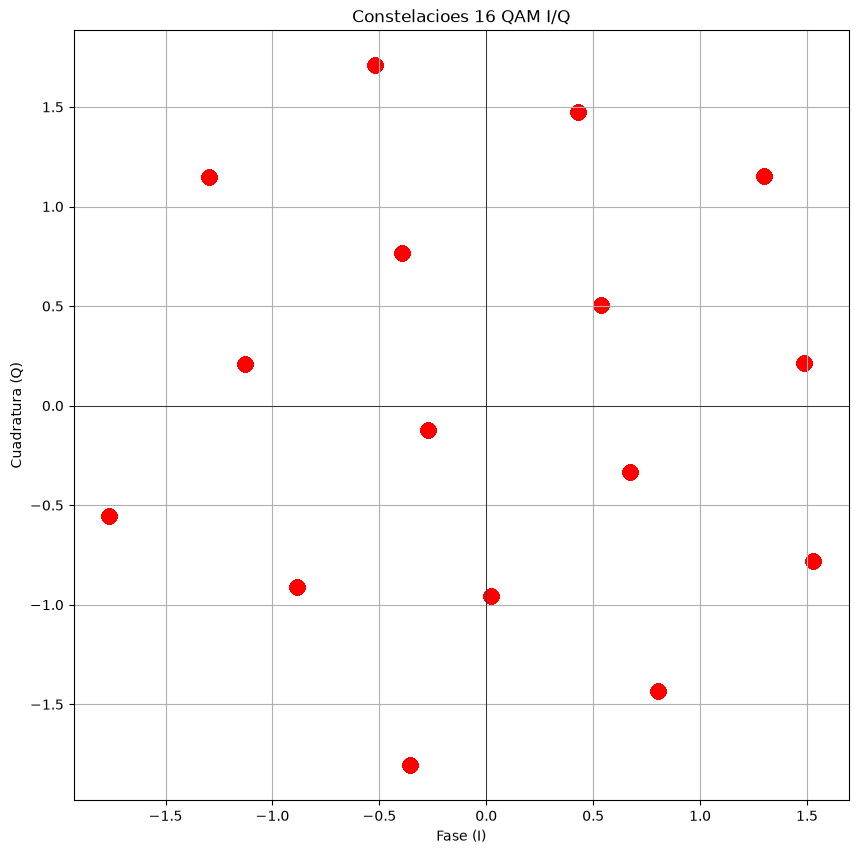

In [8]:
#-------------------------------------------+
# GRAFICAR LAS CONSTELACIONES GENERADAS POR EL ENCODER
#-------------------------------------------+
model.eval()
with torch.no_grad():
    encoder_simbols = model.encoder(x_test)
    power = torch.mean(encoder_simbols ** 2)
    constelation = (encoder_simbols / torch.sqrt(power)).numpy()

plt.figure(figsize=(10, 10))
plt.scatter(constelation[:, 0], constelation[:, 1], color='red', marker='o', s=100)
plt.grid(True)
plt.title("Constelacioes 16 QAM I/Q")
plt.xlabel("Fase (I)")
plt.ylabel("Cuadratura (Q)")
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.show()

Calculando BER para diferentes niveles de SNR:
9560
SNR: 0 dB -> BER: 0.239000
6911
SNR: 2 dB -> BER: 0.172775
4252
SNR: 4 dB -> BER: 0.106300
1983
SNR: 6 dB -> BER: 0.049575
736
SNR: 8 dB -> BER: 0.018400
87
SNR: 10 dB -> BER: 0.002175
5
SNR: 12 dB -> BER: 0.000125
0
SNR: 14 dB -> BER: 0.000000


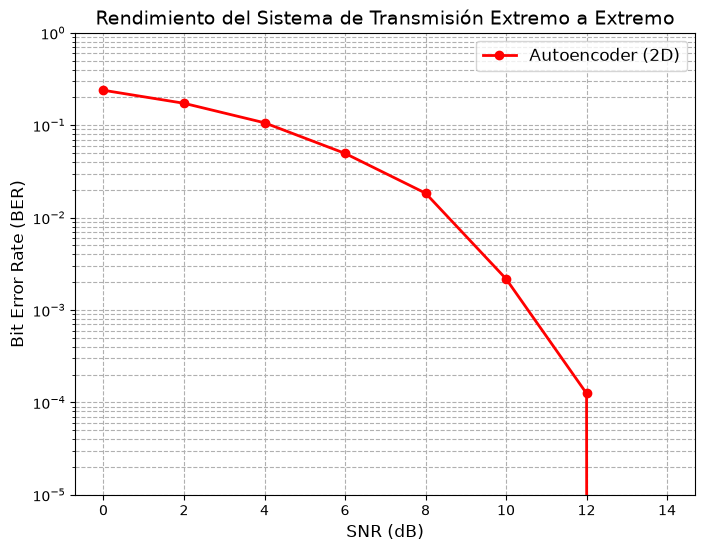

In [10]:
#-------------------------------------------+
# GRAFICAR LA CURVA DE EVALUACIÓN DE RENDIMIENTO BER(Bit error rate) VS SNR
#-------------------------------------------+
model.eval()

snr_range_dB = np.arange(0, 15, 2)                                                     #Rango de SNR (dB) a evaluar (de 0 a 14 dB)
BER_results = []
max_test = 10000                                                                       #Número de mensajes de prueba por cada nivel de SNR

# Función auxiliar para convertir la etiqueta del mensaje a su representación en bits (array de ceros y unos)
def mensaje_to_bits(mensaje_id, k_bits):
    # Convierte un entero a una lista de bits de longitud fija k
    return [int(b) for b in format(mensaje_id, f'0{k_bits}b')]

print("Calculando BER para diferentes niveles de SNR:")
with torch.no_grad():
      
    #Se convierten las etiquetas del batch de prueabas a formato binario (array de ceros y unos)
    actual_bits = np.array([mensaje_to_bits(m.item(), k) for m in y_test])

    for snr_dB in snr_range_dB:
        predictions = model(x_test, float(snr_dB))
        # El receptor elige el mensaje con el valor de logit más alto (Argmax), o sea valores de 0 a 15
        predicted_messages = torch.argmax(predictions, dim=1)
        #Se convierten los mensajes predichos a formato binario
        predicted_bits = np.array([mensaje_to_bits(m.item(), k) for m in predicted_messages])      
        #Se calcula el número total de bits erróneos
        incorret_bits = np.sum(actual_bits != predicted_bits)
        print(incorret_bits)
        total_bits = max_test * k
        #Se calcula el BER
        ber = incorret_bits / total_bits
        BER_results.append(ber)
        print(f"SNR: {snr_dB} dB -> BER: {ber:.6f}")


plt.figure(figsize=(8, 6))
plt.semilogy(snr_range_dB, BER_results, 'ro-', linewidth=2, label='Autoencoder (2D)')
plt.grid(True, which="both", linestyle="--")
plt.xlabel('SNR (dB)', fontsize=12)
plt.ylabel('Bit Error Rate (BER)', fontsize=12)
plt.title('Rendimiento del Sistema de Transmisión Extremo a Extremo', fontsize=14)
plt.legend(fontsize=12)
plt.ylim(1e-5, 1) # Escala logarítmica estándar para BER
plt.show()

